In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load all 3 datasets
train    = pd.read_csv('train.csv')
centers  = pd.read_csv('fulfilment_center_info.csv')
meals    = pd.read_csv('meal_info.csv')

print("train shape:  ", train.shape)
print("centers shape:", centers.shape)
print("meals shape:  ", meals.shape)

train shape:   (456548, 9)
centers shape: (77, 5)
meals shape:   (51, 3)


In [3]:
print("TRAIN DATA:")
print(train.head())

print("\nCENTERS DATA:")
print(centers.head())

print("\nMEALS DATA:")
print(meals.head())

TRAIN DATA:
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0          40  

CENTERS DATA:
   center_id  city_code  region_code center_type  op_area
0         11        679           56      TYPE_A      3.7
1         13        590           56      TYPE_B      6.7
2        124        590           56      

In [4]:
print("Train columns:  ", train.columns.tolist())
print("Centers columns:", centers.columns.tolist())
print("Meals columns:  ", meals.columns.tolist())

Train columns:   ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']
Centers columns: ['center_id', 'city_code', 'region_code', 'center_type', 'op_area']
Meals columns:   ['meal_id', 'category', 'cuisine']


In [5]:
# Merge train with centers on center_id
df = pd.merge(train, centers, on='center_id', how='left')

# Merge df with meals on meal_id
df = pd.merge(df, meals, on='meal_id', how='left')

print("Final merged shape:", df.shape)
print("\nAll columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Final merged shape: (456548, 15)

All columns: ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'city_code', 'region_code', 'center_type', 'op_area', 'category', 'cuisine']

First 3 rows:
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   

   emailer_for_promotion  homepage_featured  num_orders  city_code  \
0                      0                  0         177        647   
1                      0                  0         270        647   
2                      0                  0         189        647   

   region_code center_type  op_area   category cuisine  
0           56      TYPE_C      2.0  Beverages    Thai  
1           56      TYPE_C      2.0  Beverages    Thai  
2    

In [6]:
print("Missing values")
print(df.isnull().sum())


Missing values
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64


In [7]:
print("\nDataset info:")
print(df.describe())


Dataset info:
                 id           week      center_id        meal_id  \
count  4.565480e+05  456548.000000  456548.000000  456548.000000   
mean   1.250096e+06      74.768771      82.105796    2024.337458   
std    1.443548e+05      41.524956      45.975046     547.420920   
min    1.000000e+06       1.000000      10.000000    1062.000000   
25%    1.124999e+06      39.000000      43.000000    1558.000000   
50%    1.250184e+06      76.000000      76.000000    1993.000000   
75%    1.375140e+06     111.000000     110.000000    2539.000000   
max    1.499999e+06     145.000000     186.000000    2956.000000   

       checkout_price     base_price  emailer_for_promotion  \
count   456548.000000  456548.000000          456548.000000   
mean       332.238933     354.156627               0.081152   
std        152.939723     160.715914               0.273069   
min          2.970000      55.350000               0.000000   
25%        228.950000     243.500000               0.0000

In [8]:
print("num_orders stats:")
print(df['num_orders'].describe().round(1))

num_orders stats:
count    456548.0
mean        261.9
std         395.9
min          13.0
25%          54.0
50%         136.0
75%         324.0
max       24299.0
Name: num_orders, dtype: float64


In [9]:
df.to_csv('orders_merged.csv', index=False)
print("Merged dataset saved!")

Merged dataset saved!


Text(0, 0.5, 'Total Orders')

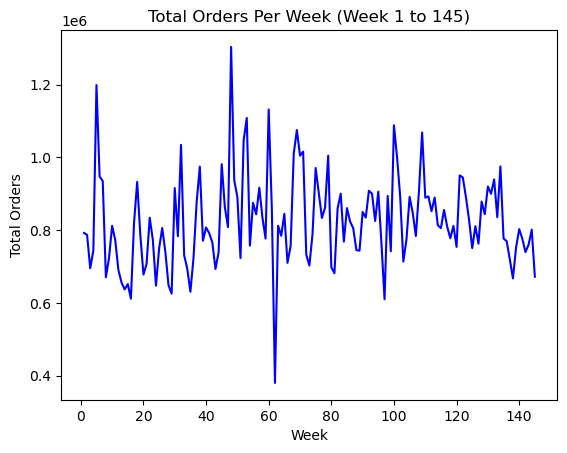

In [10]:
weekly_orders = df.groupby('week')['num_orders'].sum()

plt.plot(weekly_orders.index, weekly_orders.values, color='blue')
plt.title('Total Orders Per Week (Week 1 to 145)')
plt.xlabel('Week')
plt.ylabel('Total Orders')

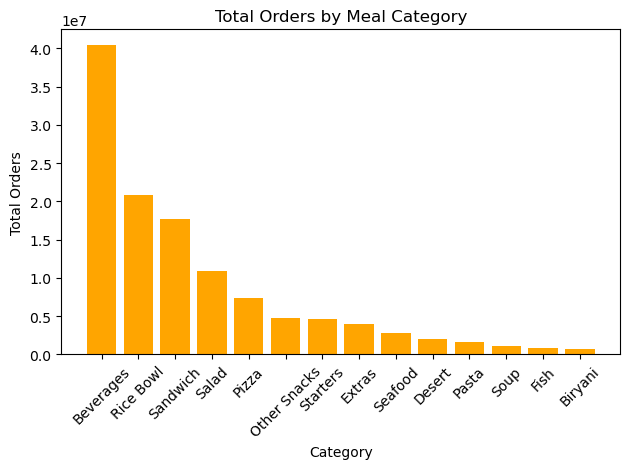

In [11]:
category_orders = df.groupby('category')['num_orders'].sum().sort_values(ascending=False)

# plt.figure(figsize=(12, 5))
plt.bar(category_orders.index, category_orders.values, color='orange')
plt.title('Total Orders by Meal Category')
plt.xlabel('Category')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()

emailer_for_promotion
0    229.3
1    631.1
Name: num_orders, dtype: float64


Text(0, 0.5, 'Average Orders')

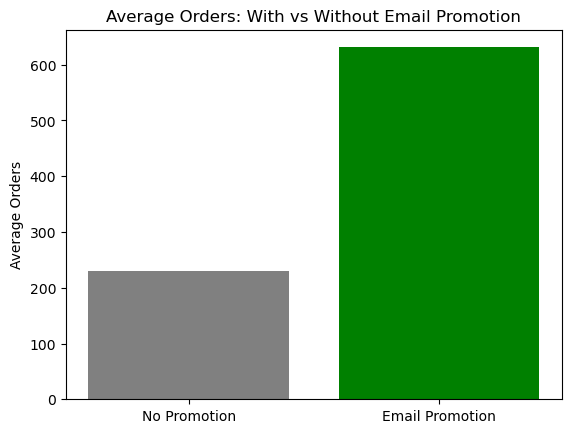

In [12]:
promo_orders = df.groupby('emailer_for_promotion')['num_orders'].mean().round(1)
print(promo_orders)


plt.bar(['No Promotion', 'Email Promotion'], promo_orders.values, color=['gray', 'green'])
plt.title('Average Orders: With vs Without Email Promotion')
plt.ylabel('Average Orders')

Text(0, 0.5, 'Total Orders')

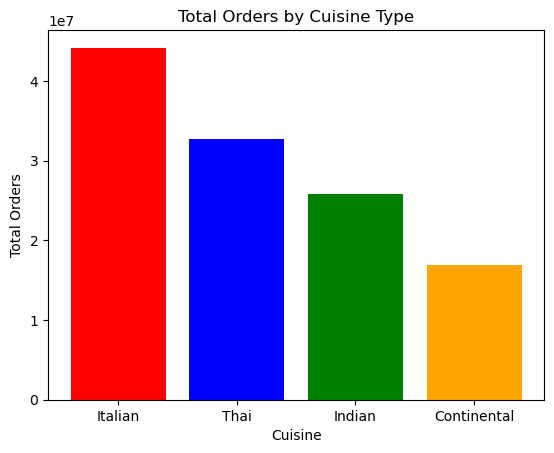

In [13]:
cuisine_orders = df.groupby('cuisine')['num_orders'].sum().sort_values(ascending=False)


plt.bar(cuisine_orders.index, cuisine_orders.values, color=['red', 'blue', 'green', 'orange'])
plt.title('Total Orders by Cuisine Type')
plt.xlabel('Cuisine')
plt.ylabel('Total Orders')

has_discount
False    217.3
True     305.9
Name: num_orders, dtype: float64


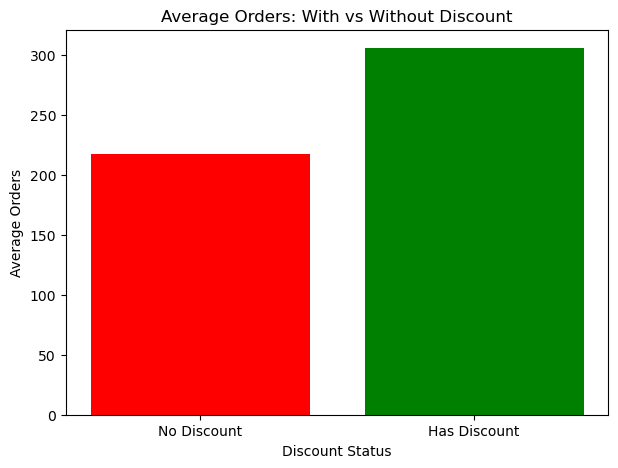

In [14]:
# Create discount column
df['discount'] = df['base_price'] - df['checkout_price']

# Split into 2 simple groups - has discount or no discount
df['has_discount'] = df['discount'] > 0

# Calculate average orders for each group
discount_orders = df.groupby('has_discount')['num_orders'].mean().round(1)
print(discount_orders)

# Plot
plt.figure(figsize=(7, 5))
plt.bar(['No Discount', 'Has Discount'], discount_orders.values, color=['red', 'green'])
plt.title('Average Orders: With vs Without Discount')
plt.xlabel('Discount Status')
plt.ylabel('Average Orders')
plt.savefig('chart5_discount_effect.png', dpi=150)
plt.show()

In [15]:
# Create useful new features from existing data

# 1 - Discount percentage
df['discount_pct'] = ((df['base_price'] - df['checkout_price']) / df['base_price'] * 100).round(1)

# 2 - Is meal on promotion (either email or homepage)
df['is_promoted'] = ((df['emailer_for_promotion'] == 1) | (df['homepage_featured'] == 1)).astype(int)

# 3 - Price difference from average
df['price_vs_avg'] = df['checkout_price'] - df['checkout_price'].mean()

# 4 - Quarter of year based on week number
df['quarter'] = pd.cut(df['week'], bins=[0, 36, 72, 108, 145],
                        labels=[1, 2, 3, 4])

print("New features added!")
print(df[['discount_pct', 'is_promoted', 'price_vs_avg', 'quarter']].head())
print("\nDataset shape:", df.shape)

New features added!
   discount_pct  is_promoted  price_vs_avg quarter
0          10.2            0   -195.408933       1
1          -0.7            0   -195.408933       1
2           0.7            0   -197.378933       1
3          22.4            0      7.261067       1
4          -0.4            0    -88.738933       1

Dataset shape: (456548, 21)


In [16]:
# Select features for model
features = ['checkout_price', 'base_price', 'discount_pct',
            'emailer_for_promotion', 'homepage_featured',
            'is_promoted', 'op_area', 'week']

# Target variable
X = df[features]
y = df['num_orders']

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)
print("\nFeatures used:", features)

Features shape: (456548, 8)
Target shape:   (456548,)

Features used: ['checkout_price', 'base_price', 'discount_pct', 'emailer_for_promotion', 'homepage_featured', 'is_promoted', 'op_area', 'week']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (365238, 8)
Test size:  (91310, 8)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("All models imported!")

All models imported!


In [19]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Accuracy
lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("Linear Regression Results:")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)

Linear Regression Results:
MAE : 200.35367506825497
RMSE: 342.9282373039922


In [20]:
import sys
!{sys.executable} -m pip install xgboost



In [25]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest Results:")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)

Random Forest Results:
MAE : 115.58731913281218
RMSE: 216.55921284675364


In [26]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("XGBoost Results:")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)

XGBoost Results:
MAE : 126.47296905517578
RMSE: 222.06630836869422


Text(0, 0.5, 'Number of Orders')

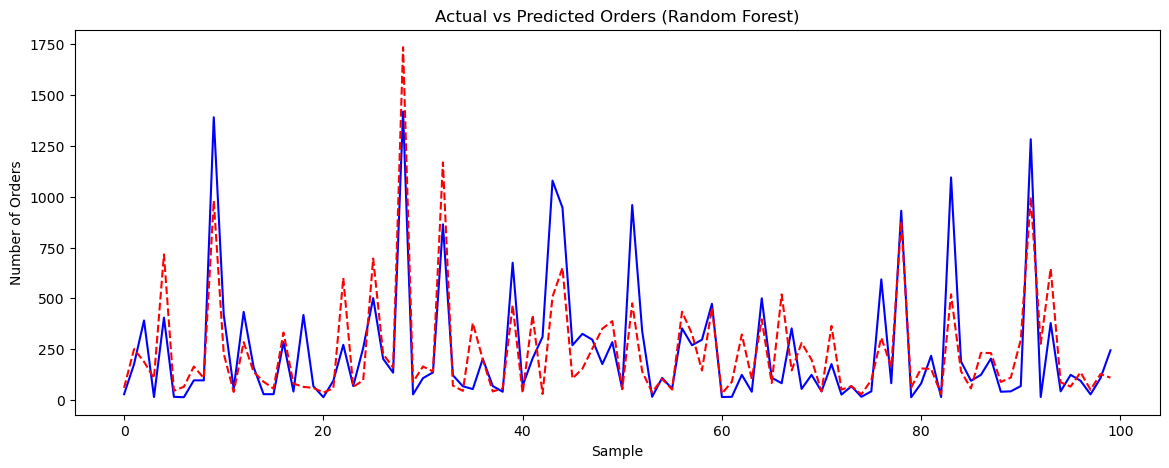

In [28]:
# Take first 100 test values to make chart readable
actual    = y_test.values[:100]
predicted = rf_predictions[:100]

plt.figure(figsize=(14, 5))
plt.plot(actual,    color='blue',  label='Actual Orders')
plt.plot(predicted, color='red',   label='Predicted Orders', linestyle='--')

plt.title('Actual vs Predicted Orders (Random Forest)')
plt.xlabel('Sample')
plt.ylabel('Number of Orders')

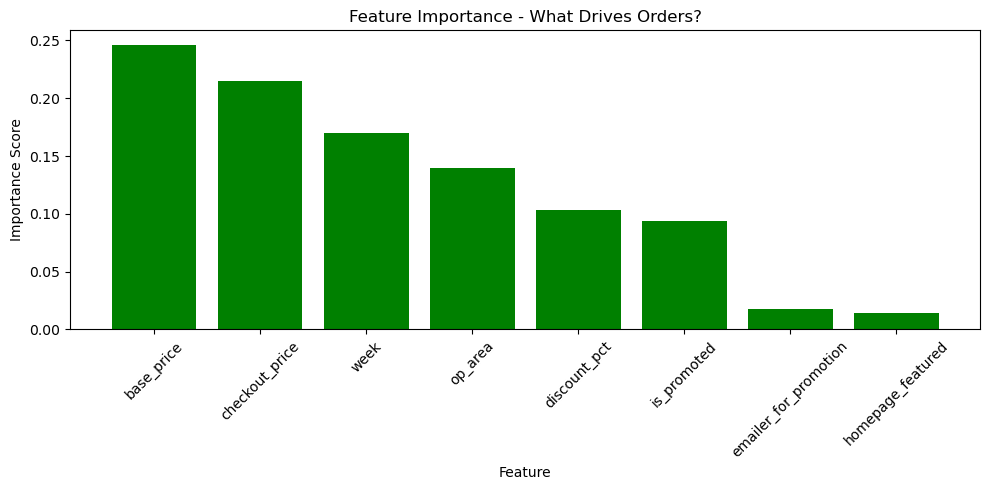

In [31]:
# Get feature importance from Random Forest
importance = pd.Series(rf_model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importance.index, importance.values, color='green')
plt.title('Feature Importance - What Drives Orders?')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()

In [2]:
print("=" * 55)
print("   NUMBER OF ORDERS PREDICTION - KEY FINDINGS")
print("=" * 55)

print("""
KEY FINDINGS:
1. Beverages is the most ordered category (40M+ orders)
   - Rice Bowl and Sandwich follow in 2nd and 3rd place
   - Biryani and Fish are the least ordered categories

2. Italian cuisine leads in total orders
   - Followed by Thai, Indian and Continental
   - Surprising finding given the Indian market context

3. Email promotion nearly triples order volume
   - Without promotion: avg 229 orders per week
   - With promotion: avg 631 orders per week

4. Discounts increase orders by 41%
   - No discount: avg 217 orders
   - With discount: avg 306 orders

5. Random Forest outperformed all other models
   - Random Forest MAE: 115.59
   - XGBoost MAE: 126.47
   - Linear Regression MAE: 200.35

BUSINESS RECOMMENDATIONS:
1. Email Marketing Strategy
   - Run email promotions consistently every week
   - Target low performing weeks to boost order volumes
   - Email campaigns are the single biggest demand driver

2. Pricing Strategy
   - Keep base price competitive as it is the top predictor
   - Avoid frequent price increases especially for Beverages
   - Use dynamic pricing during peak weeks (Week 40-60)

3. Discount Strategy
   - Apply discounts during slow weeks to recover volumes
   - Focus discounts on underperforming categories
   - Avoid over-discounting Beverages which already lead

4. Inventory Planning
   - Stock extra Beverages and Rice Bowls consistently
   - Plan extra capacity during Week 40-60 peak period
   - Use Random Forest model for weekly order forecasting

5. Homepage Features
   - Feature Italian and Thai meals on homepage
   - Rotate featured meals weekly to maintain interest
   - Combine homepage feature with email promotion for
     maximum impact on order volumes
""")
print("=" * 55)

   NUMBER OF ORDERS PREDICTION - KEY FINDINGS

KEY FINDINGS:
1. Beverages is the most ordered category (40M+ orders)
   - Rice Bowl and Sandwich follow in 2nd and 3rd place
   - Biryani and Fish are the least ordered categories

2. Italian cuisine leads in total orders
   - Followed by Thai, Indian and Continental
   - Surprising finding given the Indian market context

3. Email promotion nearly triples order volume
   - Without promotion: avg 229 orders per week
   - With promotion: avg 631 orders per week

4. Discounts increase orders by 41%
   - No discount: avg 217 orders
   - With discount: avg 306 orders

5. Random Forest outperformed all other models
   - Random Forest MAE: 115.59
   - XGBoost MAE: 126.47
   - Linear Regression MAE: 200.35

BUSINESS RECOMMENDATIONS:
1. Email Marketing Strategy
   - Run email promotions consistently every week
   - Target low performing weeks to boost order volumes
   - Email campaigns are the single biggest demand driver

2. Pricing Strategy
   